# Simple HTG Algebra


An HTG is a hierarchal tensor graph object used to encode a CREST model. 

When using a tensor graph representation, the operations performed by the model's layers, such as matrix multiplications and element-wise operations, are depicted as nodes in the tensor graph. The flow of data through the layers, represented by tensors, corresponds to the edges in the tensor graph.

In [1]:
#change crest import to appropriate location
%cd -q ..
from crest import HierarchalTensorGraph
from math import exp

/Users/draghun1/miniconda3/envs/crest_cpu/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]
/Users/draghun1/miniconda3/envs/crest_cpu/lib/python3.10/site-packages/sklearn/utils/__init__.py:15: UserWarning: A NumPy version >=1.22.4 and <1.29.0 is required for this version of SciPy (detected version 1.22.3)
  from scipy.sparse import issparse


#### Simple HTG basenodes for addition and multiplication

In [2]:
class Add(HierarchalTensorGraph):
    def __init__(self,name):
        self.name = name
    
        #call the basenode constructor
        super().__init__(lambda X : {'sum' :  X['x_1'] + X['x_2']},
                         name=name,
                         inputs={'x_1' : None, 'x_2' : None},
                         outputs={'sum' : None}
                        )
        
class Multiply(HierarchalTensorGraph):
    def __init__(self,name):
        self.name = name
        
        #call the basenode constructor
        super().__init__(lambda X : {'product' : X['scalar']*X['x']},
                         name=name,
                         inputs={'scalar' : None, 'x' : None},
                         outputs={'product' : None}
                        )

#### A Coupled HTG that to perform a*(b+c)

In [3]:
class AddMult(HierarchalTensorGraph):
    """Crest HTG to add and multiply a number"""

    def __init__(self, name):
        super().__init__(name=name,
                         inputs={'scalar': None, 'x_1': None, 'x_2': None},
                         outputs={'add_mult': None},
                         edges=[('input', Add('adder')), ('input', Multiply(
                             'multiplier')), ('adder', 'multiplier'), ('multiplier', 'output')]
                         )

        # renaming of keys
        self.rename_io(inputs_map={'sum': 'x'}, outputs_map={
                       'product': 'add_mult'}, node='multiplier')

INFO:crest.model.HierarchalTensorGraph:Created HierarchalTensorGraph adder
INFO:crest.model.HierarchalTensorGraph:Created HierarchalTensorGraph multiplier
INFO:crest.model.HierarchalTensorGraph:Created HierarchalTensorGraph add_mult
INFO:crest.model.HierarchalTensorGraph:Representing HTG add_mult
INFO:crest.model.HierarchalTensorGraph:Representing HTG adder
INFO:crest.model.HierarchalTensorGraph:Representing HTG multiplier
INFO:crest.model.HierarchalTensorGraph:Adding edges from [('input', HierarchalTensorGraph("adder", id=14414868496)), ('input', HierarchalTensorGraph("multiplier", id=4422910400)), ('adder', 'multiplier'), ('multiplier', 'output')] in HTG add_mult
INFO:crest.model.HierarchalTensorGraph:Representing HTG add_mult
INFO:crest.model.HierarchalTensorGraph:Representing HTG adder
INFO:crest.model.HierarchalTensorGraph:Adding edge from input to HierarchalTensorGraph("adder", id=14414868496) in HTG add_mult
INFO:crest.model.HierarchalTensorGraph:Representing HTG add_mult
INFO:c

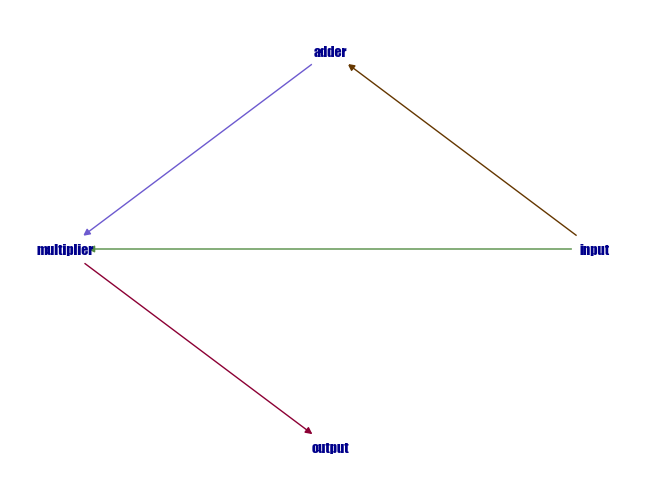

In [4]:
#create instance
import numpy as np 

add_mult = AddMult('add_mult')
add_mult.draw()

In [5]:
X = {'x_1' : 0.8, 'x_2' : 1.2, 'scalar' : 1.3}
add_mult(X)

INFO:crest.model.HierarchalTensorGraph:Calling HTG add_mult
INFO:crest.model.HierarchalTensorGraph:Checking if HTG add_mult is a basenode
INFO:crest.model.HierarchalTensorGraph:Getting all sources in HTG add_mult
INFO:crest.model.HierarchalTensorGraph:Getting all sinks in HTG add_mult
INFO:crest.model.HierarchalTensorGraph:Representing HTG add_mult
INFO:crest.model.HierarchalTensorGraph:Applying feature map to input in HTG add_mult
INFO:crest.model.HierarchalTensorGraph:Checking if HTG add_mult is a basenode
INFO:crest.model.HierarchalTensorGraph:Getting all nodes in HTG add_mult
INFO:crest.model.HierarchalTensorGraph:Getting node input in HTG add_mult
INFO:crest.model.HierarchalTensorGraph:Getting node adder in HTG add_mult
INFO:crest.model.HierarchalTensorGraph:Getting node multiplier in HTG add_mult
INFO:crest.model.HierarchalTensorGraph:Getting node output in HTG add_mult
INFO:crest.model.HierarchalTensorGraph:Representing HTG add_mult
INFO:crest.model.HierarchalTensorGraph:Getting

{'add_mult': 2.6}

#### A HTG that combines for exp(a*(b+c))

In [6]:
class Exp(HierarchalTensorGraph):
    def __init__(self,name):
        self.name = name
        
        #call the basenode constructor
        super().__init__(lambda X : {'exp' : exp(X['x'])},
                         name=name,
                         inputs={'x' : None},
                         outputs={'exp' : None}
                        )
class AddMultExp(HierarchalTensorGraph):
    
    def __init__(self):
        super().__init__(name='add_mult_exp',
                         inputs = {'x_1' : None, 'x_2' : None, 'scalar' : None},
                         outputs = {'add_mult_exp' : None},
                         edges=[('input',AddMult('add_mult')), ('add_mult',Exp('exponentiate')), ('exponentiate','output')]
                        )
        
        #define graph model
        self.rename_io(inputs_map={'add_mult':'x'},outputs_map={'exp':'add_mult_exp'},node='exponentiate')
        

In [7]:
add_mult_exp = AddMultExp()
add_mult_exp.print_edge_labels()

INFO:crest.model.HierarchalTensorGraph:Created HierarchalTensorGraph adder
INFO:crest.model.HierarchalTensorGraph:Created HierarchalTensorGraph multiplier
INFO:crest.model.HierarchalTensorGraph:Created HierarchalTensorGraph add_mult
INFO:crest.model.HierarchalTensorGraph:Representing HTG add_mult
INFO:crest.model.HierarchalTensorGraph:Representing HTG adder
INFO:crest.model.HierarchalTensorGraph:Representing HTG multiplier
INFO:crest.model.HierarchalTensorGraph:Adding edges from [('input', HierarchalTensorGraph("adder", id=4422910928)), ('input', HierarchalTensorGraph("multiplier", id=14415136128)), ('adder', 'multiplier'), ('multiplier', 'output')] in HTG add_mult
INFO:crest.model.HierarchalTensorGraph:Representing HTG add_mult
INFO:crest.model.HierarchalTensorGraph:Representing HTG adder
INFO:crest.model.HierarchalTensorGraph:Adding edge from input to HierarchalTensorGraph("adder", id=4422910928) in HTG add_mult
INFO:crest.model.HierarchalTensorGraph:Representing HTG add_mult
INFO:cr

,source,target,source output,target inputs,valid
0,input,add_mult,"['scalar', 'x_2', 'x_1']","['scalar', 'x_1', 'x_2']",True
1,add_mult,exponentiate,['x'],['x'],True
2,exponentiate,output,['add_mult_exp'],['add_mult_exp'],True


In [8]:
print(add_mult_exp(X))
add_mult_exp.print_edge_labels()

INFO:crest.model.HierarchalTensorGraph:Calling HTG add_mult_exp
INFO:crest.model.HierarchalTensorGraph:Checking if HTG add_mult_exp is a basenode
INFO:crest.model.HierarchalTensorGraph:Getting all sources in HTG add_mult_exp
INFO:crest.model.HierarchalTensorGraph:Getting all sinks in HTG add_mult_exp
INFO:crest.model.HierarchalTensorGraph:Representing HTG add_mult_exp
INFO:crest.model.HierarchalTensorGraph:Applying feature map to input in HTG add_mult_exp
INFO:crest.model.HierarchalTensorGraph:Checking if HTG add_mult_exp is a basenode
INFO:crest.model.HierarchalTensorGraph:Getting all nodes in HTG add_mult_exp
INFO:crest.model.HierarchalTensorGraph:Getting node input in HTG add_mult_exp
INFO:crest.model.HierarchalTensorGraph:Getting node add_mult in HTG add_mult_exp
INFO:crest.model.HierarchalTensorGraph:Getting node exponentiate in HTG add_mult_exp
INFO:crest.model.HierarchalTensorGraph:Getting node output in HTG add_mult_exp
INFO:crest.model.HierarchalTensorGraph:Representing HTG ad

{'add_mult_exp': 13.463738035001692}


,source,target,source output,target inputs,valid
0,input,add_mult,"['scalar', 'x_2', 'x_1']","['scalar', 'x_1', 'x_2']",True
1,add_mult,exponentiate,['x'],['x'],True
2,exponentiate,output,['add_mult_exp'],['add_mult_exp'],True


INFO:crest.model.HierarchalTensorGraph:Drawing HTG add_mult_exp
INFO:crest.model.HierarchalTensorGraph:Getting all edge labels in HTG add_mult_exp
INFO:crest.model.HierarchalTensorGraph:Getting edge label from input to add_mult in HTG add_mult_exp
INFO:crest.model.HierarchalTensorGraph:Getting node input in HTG add_mult_exp
INFO:crest.model.HierarchalTensorGraph:Getting node input in HTG add_mult_exp
INFO:crest.model.HierarchalTensorGraph:Getting node add_mult in HTG add_mult_exp
INFO:crest.model.HierarchalTensorGraph:Getting node add_mult in HTG add_mult_exp
INFO:crest.model.HierarchalTensorGraph:Getting edge label from add_mult to exponentiate in HTG add_mult_exp
INFO:crest.model.HierarchalTensorGraph:Getting node add_mult in HTG add_mult_exp
INFO:crest.model.HierarchalTensorGraph:Getting node add_mult in HTG add_mult_exp
INFO:crest.model.HierarchalTensorGraph:Getting node exponentiate in HTG add_mult_exp
INFO:crest.model.HierarchalTensorGraph:Getting node exponentiate in HTG add_mul

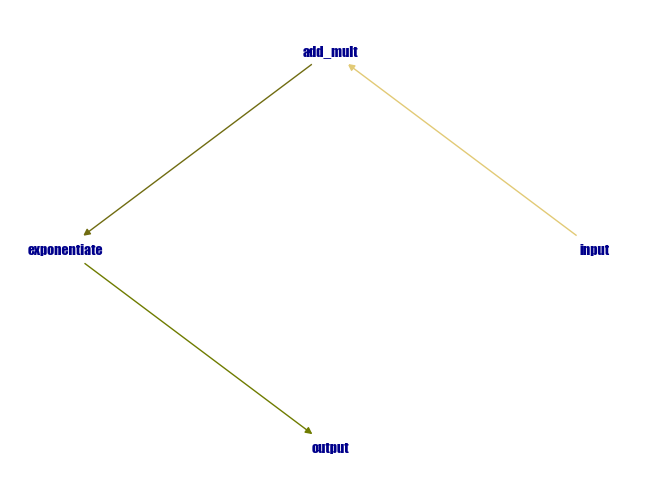

In [9]:
#draw the graph
add_mult_exp.draw()

INFO:crest.model.HierarchalTensorGraph:Drawing HTG add_mult_exp
INFO:crest.model.HierarchalTensorGraph:Representing HTG add_mult_exp
INFO:crest.model.HierarchalTensorGraph:Expanding node add_mult in HTG add_mult_exp
INFO:crest.model.HierarchalTensorGraph:Getting node add_mult in HTG add_mult_exp
INFO:crest.model.HierarchalTensorGraph:Checking if HTG add_mult is a basenode
INFO:crest.model.HierarchalTensorGraph:Getting node add_mult in HTG add_mult_exp
INFO:crest.model.HierarchalTensorGraph:Getting all edges in HTG add_mult
INFO:crest.model.HierarchalTensorGraph:Getting node add_mult in HTG add_mult_exp
INFO:crest.model.HierarchalTensorGraph:Getting all nodes in HTG add_mult
INFO:crest.model.HierarchalTensorGraph:Getting all edge labels in HTG add_mult_exp
INFO:crest.model.HierarchalTensorGraph:Getting edge label from input to add_mult.adder in HTG add_mult_exp
INFO:crest.model.HierarchalTensorGraph:Getting node input in HTG add_mult_exp
INFO:crest.model.HierarchalTensorGraph:Getting no

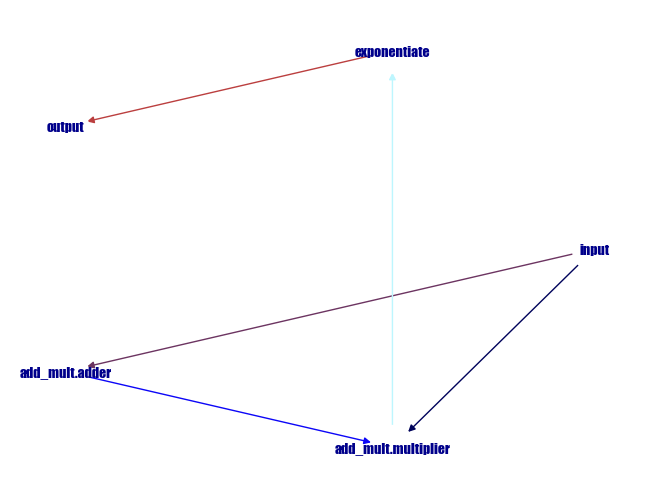

In [10]:
#draw the graph with add_mult expanded
add_mult_exp.draw(expand_nodes='add_mult')

INFO:crest.model.HierarchalTensorGraph:Drawing HTG add_mult_exp
INFO:crest.model.HierarchalTensorGraph:Checking if HTG input is a basenode
INFO:crest.model.HierarchalTensorGraph:Checking if HTG add_mult is a basenode
INFO:crest.model.HierarchalTensorGraph:Checking if HTG input is a basenode
INFO:crest.model.HierarchalTensorGraph:Checking if HTG add_mult is a basenode
INFO:crest.model.HierarchalTensorGraph:Representing HTG add_mult_exp
INFO:crest.model.HierarchalTensorGraph:Expanding node add_mult in HTG add_mult_exp
INFO:crest.model.HierarchalTensorGraph:Getting node add_mult in HTG add_mult_exp
INFO:crest.model.HierarchalTensorGraph:Checking if HTG add_mult is a basenode
INFO:crest.model.HierarchalTensorGraph:Getting node add_mult in HTG add_mult_exp
INFO:crest.model.HierarchalTensorGraph:Getting all edges in HTG add_mult
INFO:crest.model.HierarchalTensorGraph:Getting node add_mult in HTG add_mult_exp
INFO:crest.model.HierarchalTensorGraph:Getting all nodes in HTG add_mult
INFO:crest.

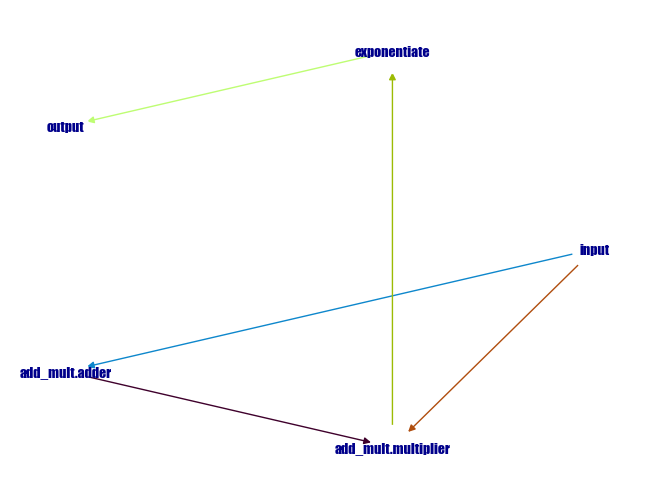

In [11]:
#draw the graph with everything expanded
add_mult_exp.draw(expand_nodes='all')

In [12]:
add_mult_exp.print_edge_labels(expand_nodes='all')

INFO:crest.model.HierarchalTensorGraph:Printing all edge labels in HTG add_mult_exp
INFO:crest.model.HierarchalTensorGraph:Checking if HTG input is a basenode
INFO:crest.model.HierarchalTensorGraph:Checking if HTG add_mult is a basenode
INFO:crest.model.HierarchalTensorGraph:Checking if HTG input is a basenode
INFO:crest.model.HierarchalTensorGraph:Checking if HTG add_mult is a basenode
INFO:crest.model.HierarchalTensorGraph:Representing HTG add_mult_exp
INFO:crest.model.HierarchalTensorGraph:Expanding node add_mult in HTG add_mult_exp
INFO:crest.model.HierarchalTensorGraph:Getting node add_mult in HTG add_mult_exp
INFO:crest.model.HierarchalTensorGraph:Checking if HTG add_mult is a basenode
INFO:crest.model.HierarchalTensorGraph:Getting node add_mult in HTG add_mult_exp
INFO:crest.model.HierarchalTensorGraph:Getting all edges in HTG add_mult
INFO:crest.model.HierarchalTensorGraph:Getting node add_mult in HTG add_mult_exp
INFO:crest.model.HierarchalTensorGraph:Getting all nodes in HTG 

,source,target,source output,target inputs,valid
0,input,add_mult.adder,"['scalar', 'x_2', 'x_1']","['x_2', 'x_1']",True
1,input,add_mult.multiplier,"['scalar', 'x_2', 'x_1']","['scalar', 'x']",True
2,exponentiate,output,['add_mult_exp'],['add_mult_exp'],True
3,add_mult.adder,add_mult.multiplier,['x'],"['scalar', 'x']",True
4,add_mult.multiplier,exponentiate,['x'],['x'],True


In [13]:
add_mult.print_edge_labels()

INFO:crest.model.HierarchalTensorGraph:Printing all edge labels in HTG add_mult
INFO:crest.model.HierarchalTensorGraph:Getting all edge labels in HTG add_mult
INFO:crest.model.HierarchalTensorGraph:Getting edge label from input to adder in HTG add_mult
INFO:crest.model.HierarchalTensorGraph:Getting node input in HTG add_mult
INFO:crest.model.HierarchalTensorGraph:Getting node input in HTG add_mult
INFO:crest.model.HierarchalTensorGraph:Getting node adder in HTG add_mult
INFO:crest.model.HierarchalTensorGraph:Getting node adder in HTG add_mult
INFO:crest.model.HierarchalTensorGraph:Getting edge label from input to multiplier in HTG add_mult
INFO:crest.model.HierarchalTensorGraph:Getting node input in HTG add_mult
INFO:crest.model.HierarchalTensorGraph:Getting node input in HTG add_mult
INFO:crest.model.HierarchalTensorGraph:Getting node multiplier in HTG add_mult
INFO:crest.model.HierarchalTensorGraph:Getting node multiplier in HTG add_mult
INFO:crest.model.HierarchalTensorGraph:Getting

,source,target,source output,target inputs,valid
0,input,adder,"['scalar', 'x_1', 'x_2']","['x_2', 'x_1']",True
1,input,multiplier,"['scalar', 'x_1', 'x_2']","['scalar', 'x']",True
2,adder,multiplier,['x'],"['scalar', 'x']",True
3,multiplier,output,['add_mult'],['add_mult'],True
